<a href="https://colab.research.google.com/github/Gowtham60/Build_Sprint_AI/blob/main/Final_nifty_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 📦 Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import io

**Reasoning**:
Load the dataset "nifty_project.csv" into a pandas DataFrame and display the first 5 rows.



In [ ]:
# Mount Google Drive (optional, if your file is stored in Drive)
from google.colab import drive
drive.mount('/content/drive')

# Upload CSV manually from local system
# from google.colab import files
# uploaded = files.upload()

# filename = list(uploaded.keys())[0]  # Get the name of the uploaded file
# df = pd.read_csv(io.BytesIO(uploaded[filename]))
# df.head()  # Display the first few rows

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


date        0
price       0
open        0
high        0
low         0
vol.        0
change %    0
MA7         0
MA21        0
RSI         0
dtype: int64
                                date         price          open  \
count                           1548   1548.000000   1548.000000   
mean   2022-03-16 21:56:16.744186112  16808.301098  16818.680297   
min              2019-01-29 00:00:00   7610.250000   7735.150000   
25%              2020-08-24 18:00:00  12029.962500  12051.325000   
50%              2022-03-14 12:00:00  17210.125000  17205.600000   
75%              2023-10-09 06:00:00  19676.737500  19674.712500   
max              2025-05-06 00:00:00  26216.050000  26248.250000   
std                              NaN   4552.464941   4551.273739   

               high           low         vol.     change %           MA7  \
count   1548.000000   1548.000000  1548.000000  1548.000000   1548.000000   
mean   16899.391828  16711.814632   388.112797     0.059412  16782.241616   
min

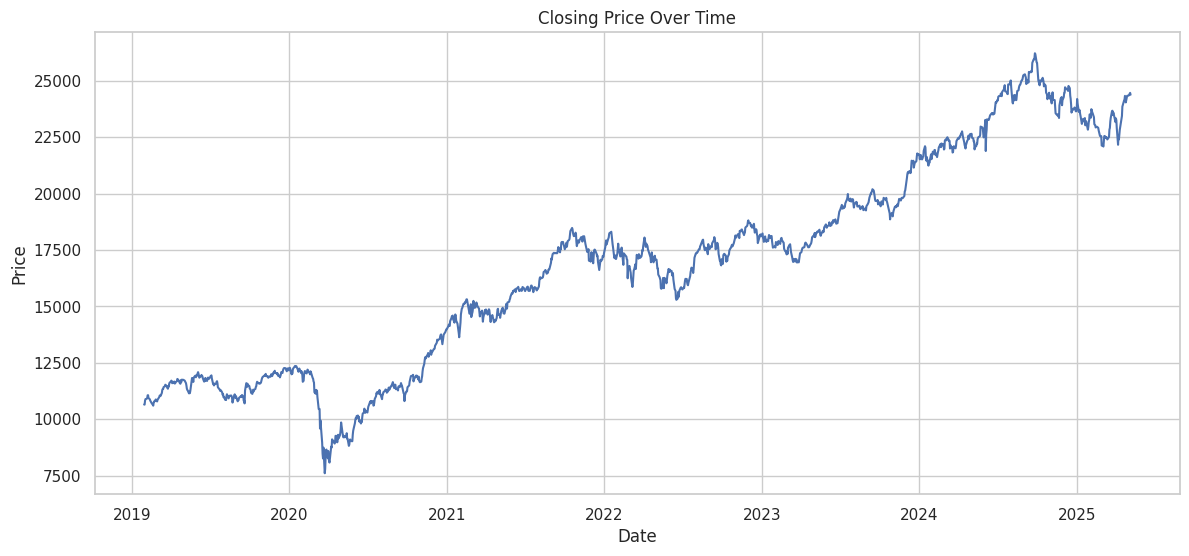

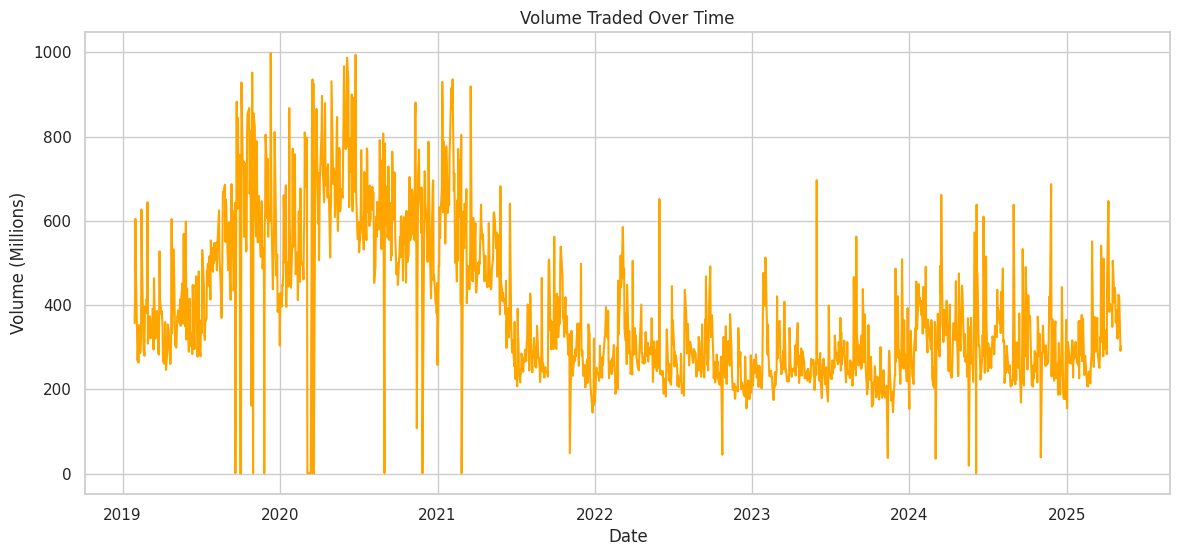

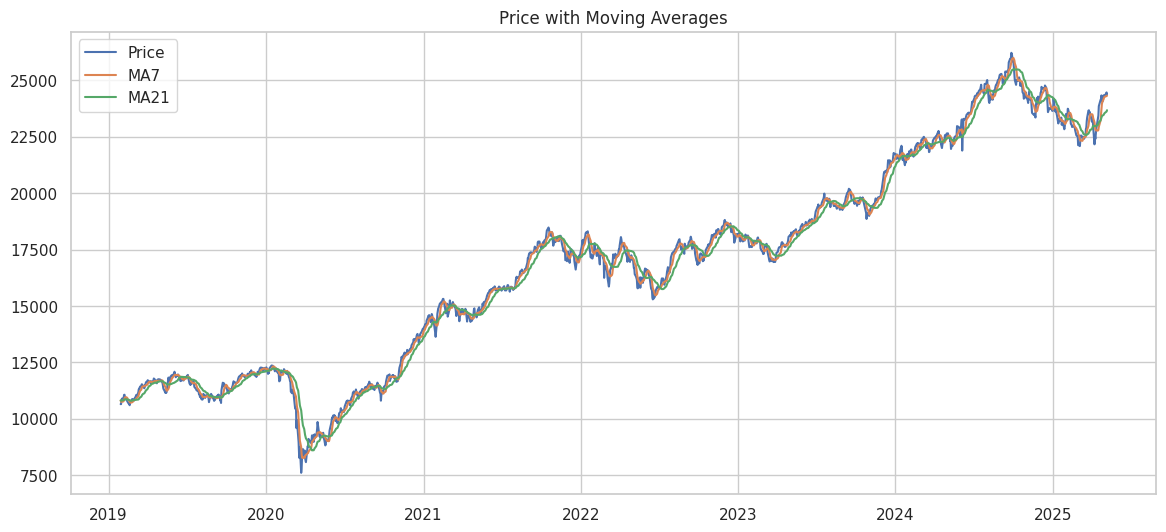

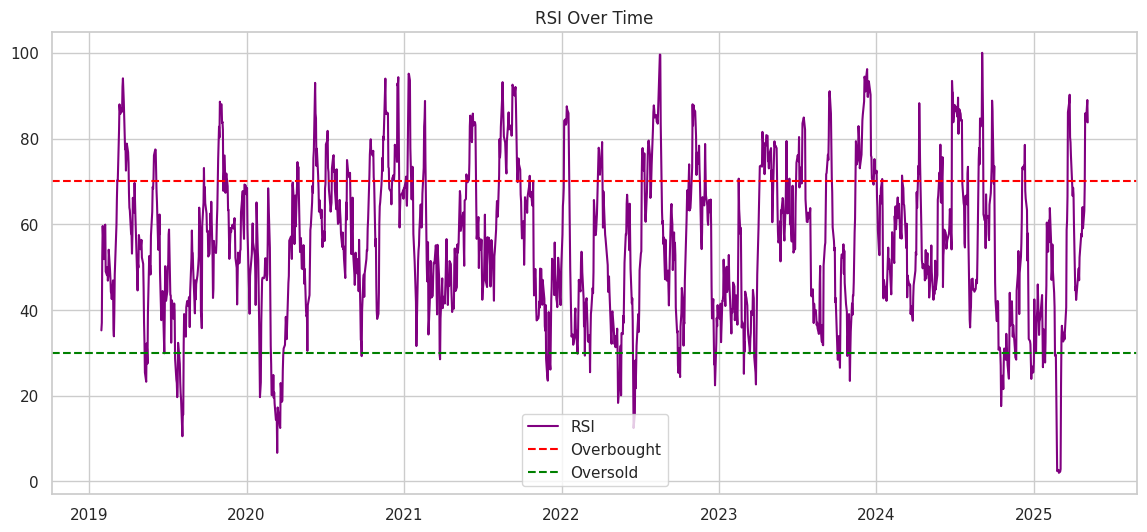

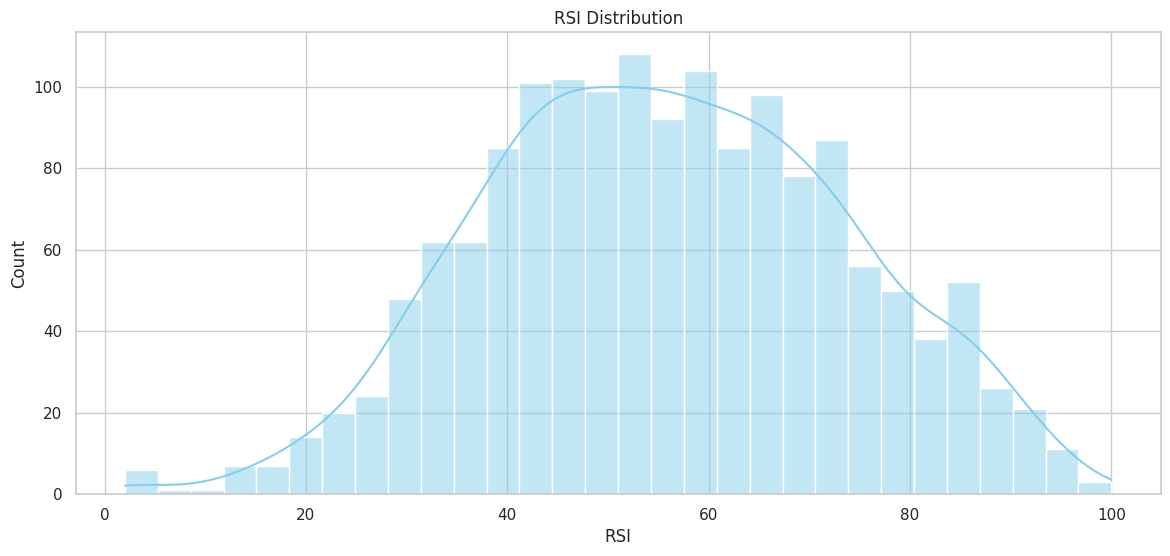

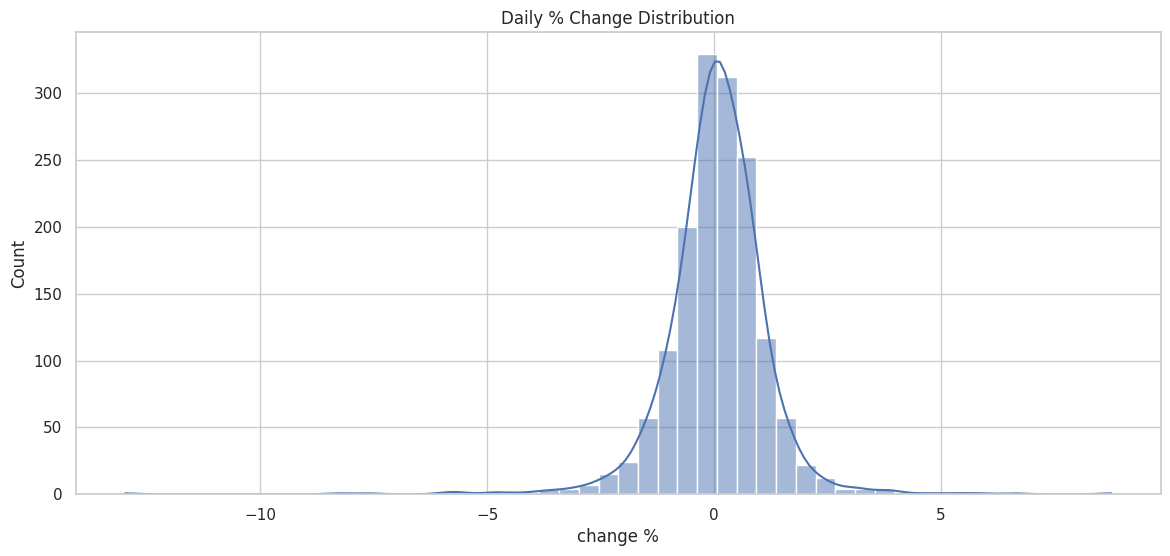

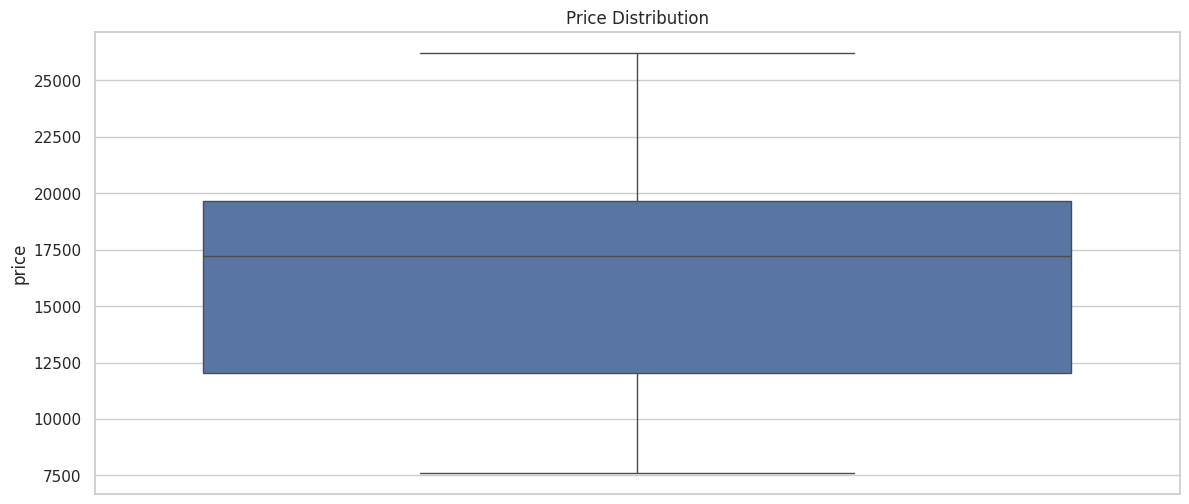

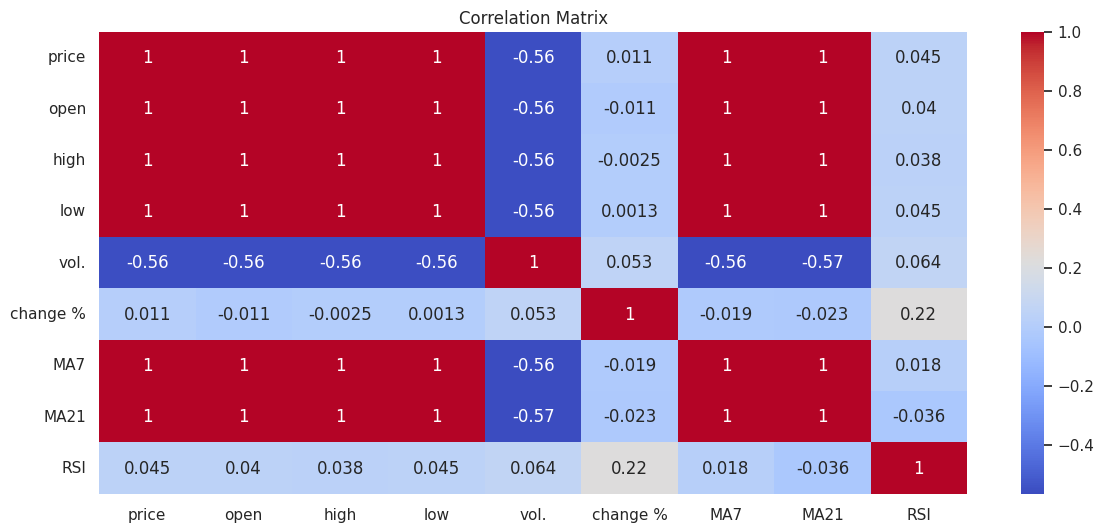

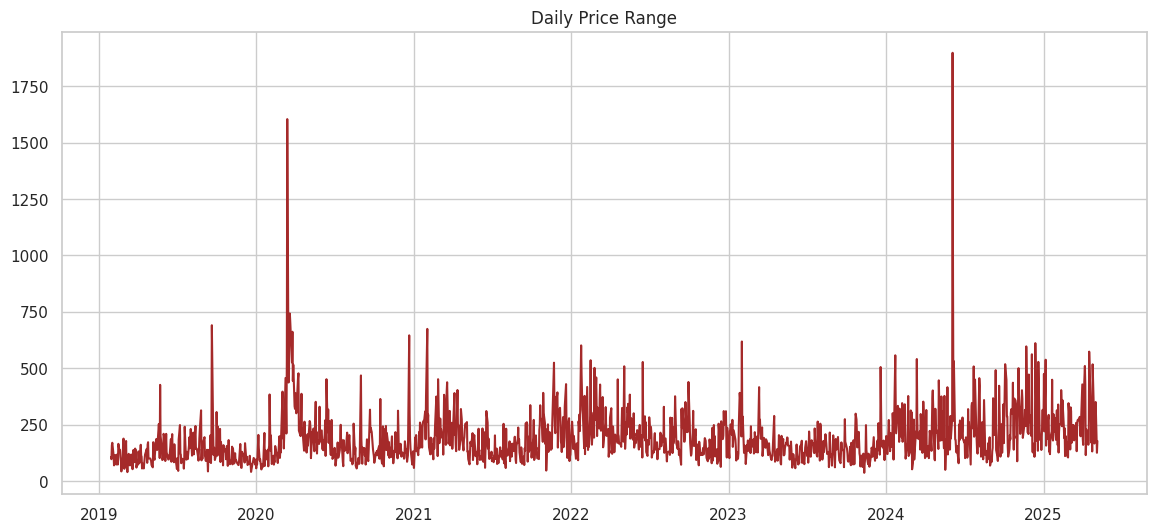

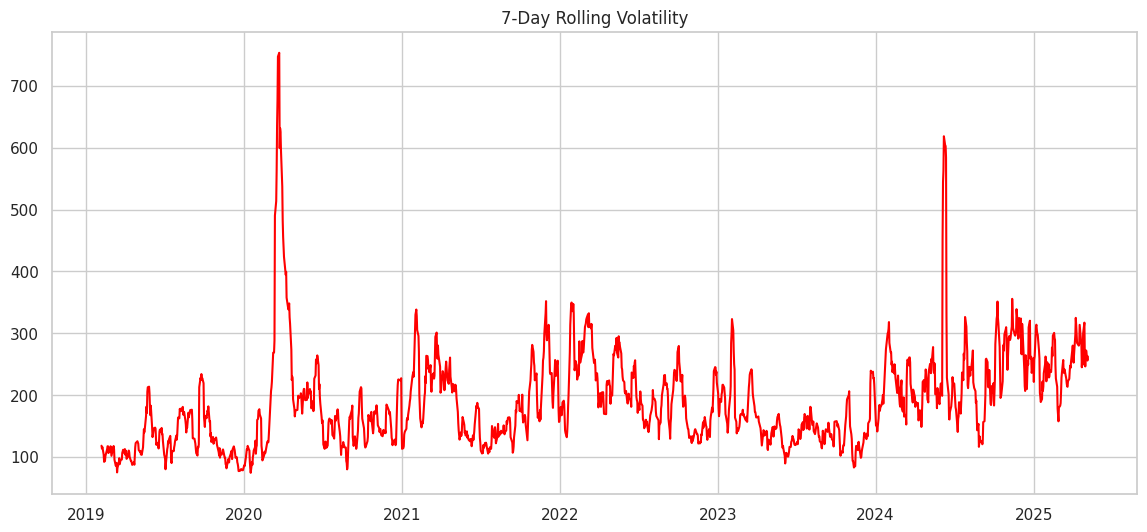

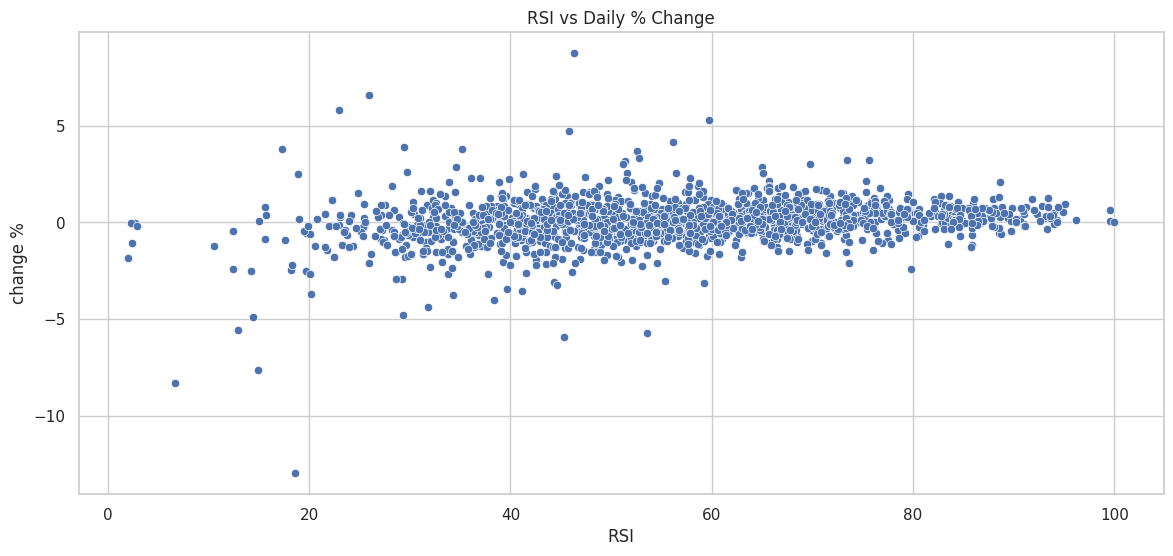

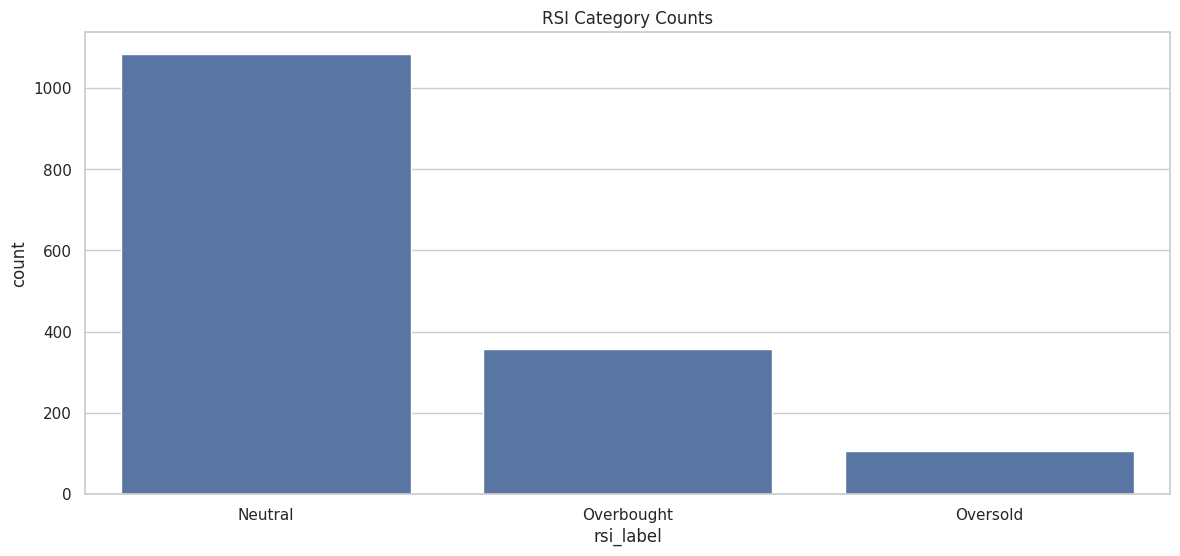

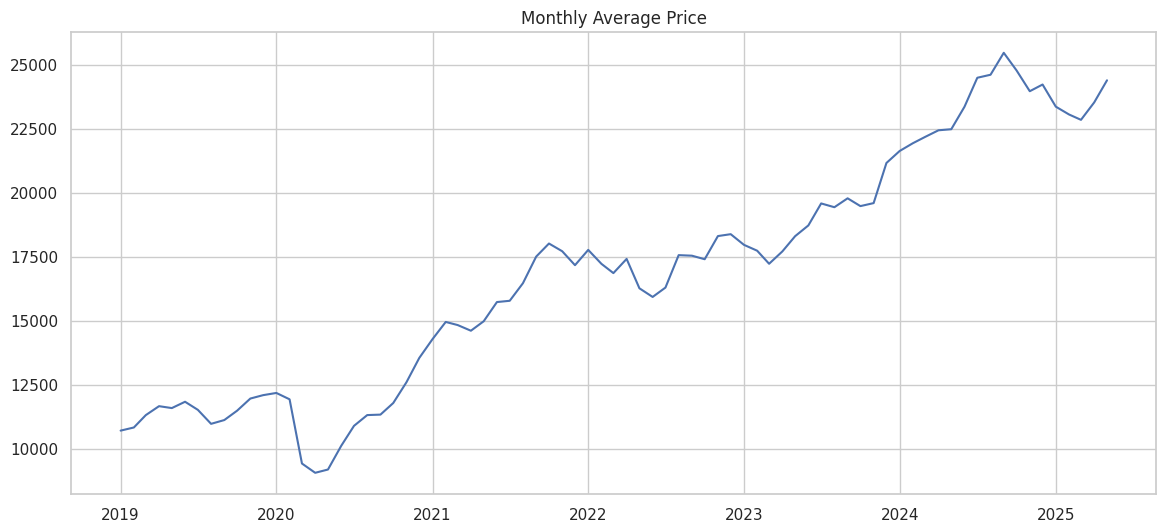

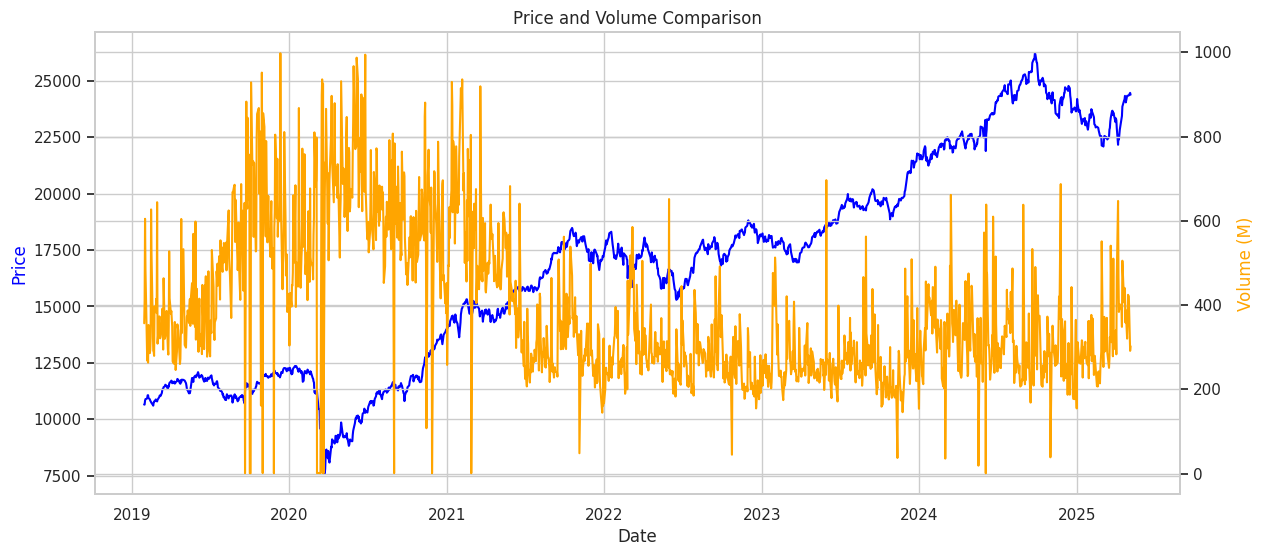

Highest Price Day:
date             2024-09-26 00:00:00
price                       26216.05
open                         26005.4
high                         26250.9
low                          25998.4
vol.                           370.9
change %                        0.81
MA7                     25811.992857
MA21                    25393.807143
RSI                        88.835421
daily_range                    252.5
volatility_7d             214.642857
rsi_label                 Overbought
month                              9
year                            2024
Name: 1399, dtype: object
Lowest Price Day:
date             2020-03-23 00:00:00
price                        7610.25
open                          7945.7
high                         8159.25
low                           7583.6
vol.                          653.54
change %                      -12.98
MA7                      8743.942857
MA21                    10374.990476
RSI                        18.591733
daily_range 

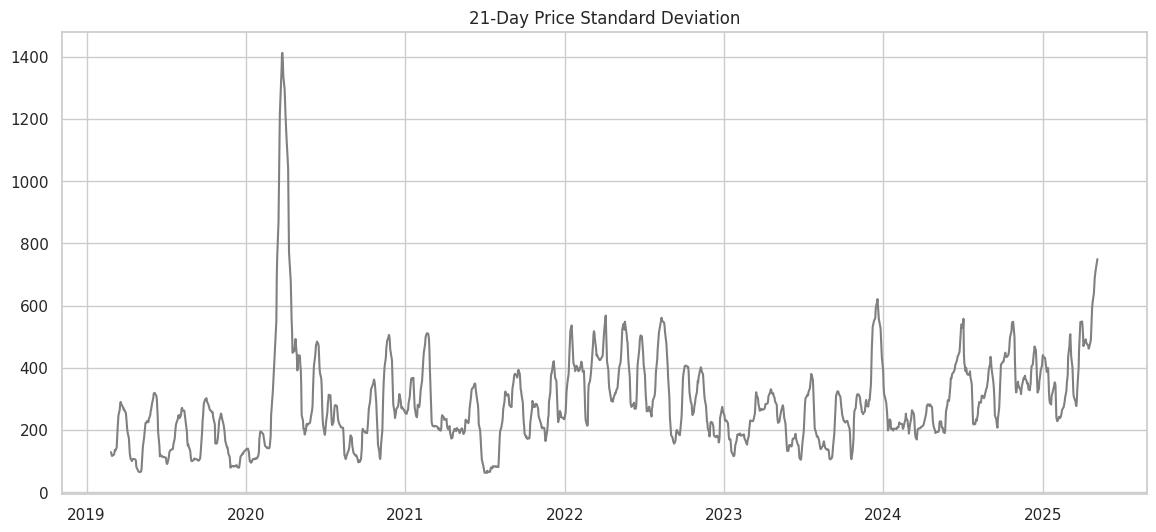

Signal Change Days:
         date     price           MA7  signal
0  2019-01-29  10652.20  10808.600000       0
2  2019-01-31  10830.95  10751.192857       1
8  2019-02-08  10943.60  10949.521429       0
16 2019-02-20  10735.45  10725.178571       1
22 2019-02-28  10792.50  10804.500000       0
Yearly Summary Statistics:
             price                                   change %               \
              mean       max       min          std      mean   max    min   
year                                                                         
2019  11486.720889  12271.80  10604.35   433.751285  0.062756  5.32  -2.14   
2020  11161.474802  13981.95   7610.25  1411.134117  0.074563  8.76 -12.98   
2021  16026.760685  18477.05  13634.60  1285.160097  0.091734  4.74  -3.76   
2022  17243.082996  18812.50  15293.50   835.884885  0.020364  3.03  -4.78   
2023  18910.279592  21778.70  16945.05  1104.054388  0.075388  2.07  -1.61   
2024  23490.831984  26216.05  21238.80  1285.696777  

In [ ]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Set plot styles
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 3. Load dataset
import pandas as pd

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/nifty_project.csv")
df.columns = [c.lower() for c in df.columns]
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df['price'] = df['price'].str.replace(',', '').astype(float)
df['open'] = df['open'].str.replace(',', '').astype(float)
df['high'] = df['high'].str.replace(',', '').astype(float)
open_values = df['open'].tolist()
df['low'] = df['low'].str.replace(',', '').astype(float)
df['vol.'] = df['vol.'].str.replace(',', '').str.replace('M', '').str.replace('B','').astype(float)
df['change %'] = df['change %'].str.replace('%','').astype(float)
df.set_index('date', inplace=True)
df.sort_values('date', inplace=True)

# 📘 Step 2: Technical Indicators
df['MA7'] = df['price'].rolling(7).mean()
df['MA21'] = df['price'].rolling(21).mean()
delta = df['price'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))
df.dropna(inplace=True)
df.reset_index(inplace=True)


# 10. Check for missing values
print(df.isnull().sum())

# 11. Summary statistics
print(df.describe())

# 12. Plot closing price over time
plt.plot(df['date'], df['price'])
plt.title('Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# 13. Plot volume over time
plt.plot(df['date'], df['vol.'], color='orange')
plt.title('Volume Traded Over Time')
plt.xlabel('Date')
plt.ylabel('Volume (Millions)')
plt.show()

# 14. Plot moving averages
plt.plot(df['date'], df['price'], label='Price')
plt.plot(df['date'], df['MA7'], label='MA7')
plt.plot(df['date'], df['MA21'], label='MA21')
plt.title('Price with Moving Averages')
plt.legend()
plt.show()

# 15. Plot RSI
plt.plot(df['date'], df['RSI'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--', label='Overbought')
plt.axhline(30, color='green', linestyle='--', label='Oversold')
plt.title('RSI Over Time')
plt.legend()
plt.show()

# 16. Histogram of RSI
sns.histplot(df['RSI'], bins=30, kde=True, color='skyblue')
plt.title('RSI Distribution')
plt.show()

# 17. Histogram of % change
sns.histplot(df['change %'], bins=50, kde=True)
plt.title('Daily % Change Distribution')
plt.show()

# 18. Boxplot of price
sns.boxplot(df['price'])
plt.title('Price Distribution')
plt.show()

# 19. Correlation matrix
corr = df[['price', 'open', 'high', 'low', 'vol.', 'change %', 'MA7', 'MA21', 'RSI']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# 20. Daily volatility
df['daily_range'] = df['high'] - df['low']
plt.plot(df['date'], df['daily_range'], color='brown')
plt.title('Daily Price Range')
plt.show()

# 21. 7-day volatility
df['volatility_7d'] = df['daily_range'].rolling(window=7).mean()
plt.plot(df['date'], df['volatility_7d'], color='red')
plt.title('7-Day Rolling Volatility')
plt.show()

# 22. Scatterplot of RSI vs %change
sns.scatterplot(x='RSI', y='change %', data=df)
plt.title('RSI vs Daily % Change')
plt.show()

# 23. Highlight overbought/oversold RSI zones
df['rsi_label'] = df['RSI'].apply(lambda x: 'Overbought' if x > 70 else 'Oversold' if x < 30 else 'Neutral')
sns.countplot(x='rsi_label', data=df)
plt.title('RSI Category Counts')
plt.show()

# 24. Add month and year columns
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# 25. Monthly average price
monthly_avg = df.groupby(['year', 'month'])['price'].mean().reset_index()
monthly_avg['date'] = pd.to_datetime(monthly_avg[['year', 'month']].assign(day=1))
plt.plot(monthly_avg['date'], monthly_avg['price'])
plt.title('Monthly Average Price')
plt.show()

# 26. Volume and price comparison
fig, ax1 = plt.subplots()
ax1.set_xlabel('Date')
ax1.set_ylabel('Price', color='blue')
ax1.plot(df['date'], df['price'], color='blue')
ax2 = ax1.twinx()
ax2.set_ylabel('Volume (M)', color='orange')
ax2.plot(df['date'], df['vol.'], color='orange')
plt.title('Price and Volume Comparison')
plt.show()

# 27. Identify highest price point
max_price = df.loc[df['price'].idxmax()]
print("Highest Price Day:")
print(max_price)

# 28. Identify lowest price point
min_price = df.loc[df['price'].idxmin()]
print("Lowest Price Day:")
print(min_price)

# 29. Rolling std deviation for 21 days
df['stddev_21'] = df['price'].rolling(window=21).std()
plt.plot(df['date'], df['stddev_21'], color='gray')
plt.title('21-Day Price Standard Deviation')
plt.show()

# 30. Create signal column for price > MA7
df['signal'] = np.where(df['price'] > df['MA7'], 1, 0)
signal_change_days = df[df['signal'].diff() != 0]
print("Signal Change Days:")
print(signal_change_days[['date', 'price', 'MA7', 'signal']].head())

# # 31. Candlestick-like bar chart (simplified)
# df['color'] = df['change %'].apply(lambda x: 'green' if x > 0 else 'red')
# plt.bar(df['date'], df['price'], color=df['color'])
# plt.title('Price Movement Color Bar')
# plt.show()

# 32. Summary statistics grouped by year
yearly_stats = df.groupby('year')[['price', 'change %', 'RSI']].agg(['mean', 'max', 'min', 'std'])
print("Yearly Summary Statistics:")
print(yearly_stats)

# 33. Detect consecutive gains/losses
df['gain'] = df['change %'] > 0
df['streak'] = df['gain'].astype(int).groupby((df['gain'] != df['gain'].shift()).cumsum()).cumsum()
longest_gain = df['streak'].max()
print(f"Longest consecutive gains: {longest_gain} days")

# 34. Save cleaned data
df.to_csv("market_data_cleaned.csv", index=False)

# 35. End of EDA script
print("EDA complete.")


DEBUG:cmdstanpy:input tempfile: /tmp/tmpje438a4s/ku7xrg87.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpje438a4s/3rwz75zv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=58866', 'data', 'file=/tmp/tmpje438a4s/ku7xrg87.json', 'init=/tmp/tmpje438a4s/3rwz75zv.json', 'output', 'file=/tmp/tmpje438a4s/prophet_modelm8di1193/prophet_model-20250527042620.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
04:26:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:26:22 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
<ipython-input-4-23641318b03b>:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHA

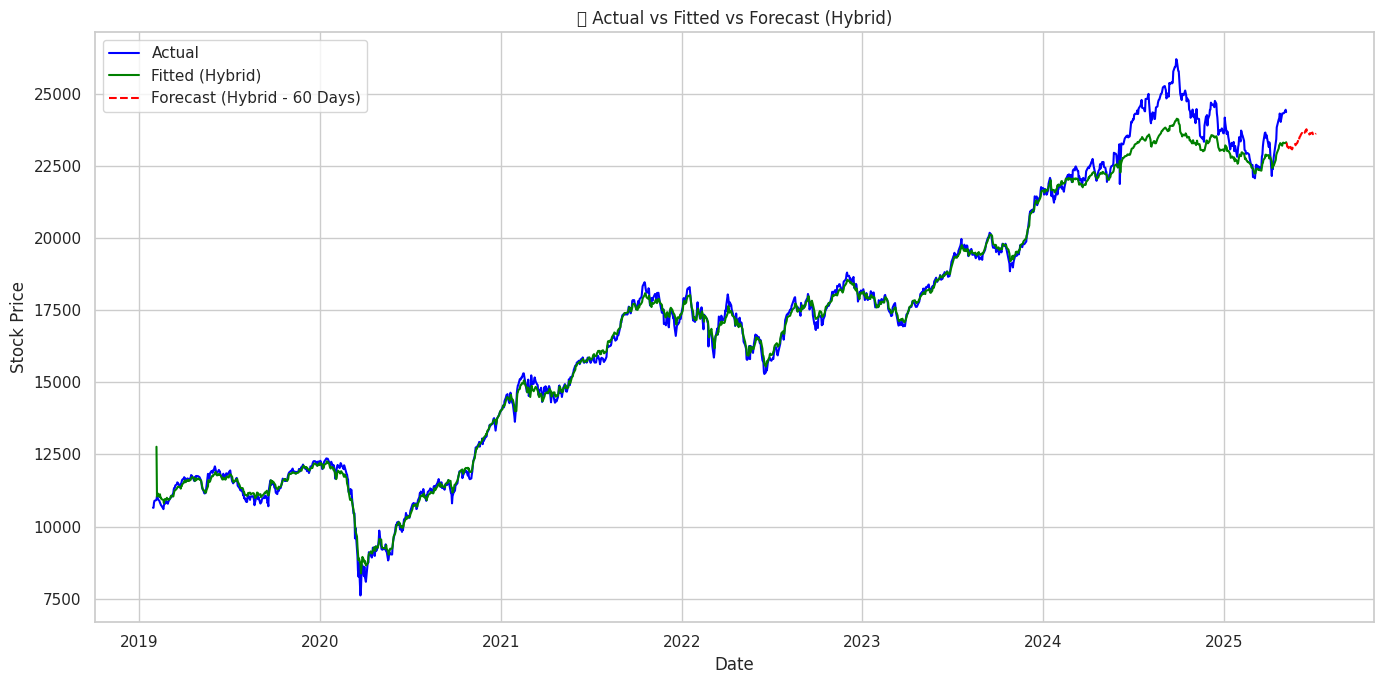

✅ Forecast saved to hybrid_60_day_forecast.csv


In [ ]:
# 📘 Imports
!pip install prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# ✅ Suppress convergence warnings
warnings.simplefilter('ignore', ConvergenceWarning)

# 📘 Step 1: Load & Clean Data
df = pd.read_csv("/content/drive/MyDrive/nifty_project.csv")
df.columns = [c.lower() for c in df.columns]
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df['price'] = df['price'].str.replace(',', '').astype(float)
df.set_index('date', inplace=True)
df.sort_values('date', inplace=True)

# 📘 Step 2: Technical Indicators
df['MA7'] = df['price'].rolling(7).mean()
df['MA21'] = df['price'].rolling(21).mean()
delta = df['price'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))
df.dropna(inplace=True)
df.reset_index(inplace=True)

# 📘 Step 3: XGBoost Features
def create_features(df, lag=5):
    X, y = [], []
    for i in range(lag, len(df)):
        price_lags = df['price'].iloc[i-lag:i].values
        indicators = df[['MA7', 'MA21', 'RSI']].iloc[i].values
        features = np.concatenate([price_lags, indicators]).astype(float)
        X.append(features)
        y.append(df['price'].iloc[i])
    return np.array(X), np.array(y)

lag = 5
X, y = create_features(df, lag)
train_size = int(len(X)*0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 📘 Step 4: XGBoost Tuning
xgb_model = XGBRegressor()
param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [4, 8],
    'learning_rate': [0.01, 0.05]
}
tscv = TimeSeriesSplit(n_splits=3)
xgb_search = GridSearchCV(xgb_model, param_grid, cv=tscv, scoring='neg_mean_squared_error')
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
xgb_fitted = best_xgb.predict(np.concatenate([X_train, X_test]))

# 📘 Step 5: SARIMA Grid Search (Simplified + Convergence Check)
p = q = range(0, 3)
d = [1]
pdq = list(product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 5) for x in pdq]

best_aic = float("inf")
best_order = None
best_seasonal_order = None

for param in pdq:
    for seasonal_param in seasonal_pdq:
        try:
            mod = SARIMAX(df['price'], order=param, seasonal_order=seasonal_param,
                          enforce_stationarity=False, enforce_invertibility=False)
            results = mod.fit(disp=False)
            if results.mle_retvals['converged'] and results.aic < best_aic:
                best_aic = results.aic
                best_order = param
                best_seasonal_order = seasonal_param
        except:
            continue

sarima_model = SARIMAX(df['price'], order=best_order, seasonal_order=best_seasonal_order).fit(disp=False)
sarima_fitted = sarima_model.fittedvalues

# 📘 Step 6: Prophet Model
prophet_df = df[['date', 'price']].rename(columns={'date': 'ds', 'price': 'y'})
prophet = Prophet(daily_seasonality=True)
prophet.fit(prophet_df)
prophet_forecast_df = prophet.predict(prophet_df)
prophet_fitted = prophet_forecast_df['yhat'].values

# 📘 Step 7: Hybrid Fitted
min_len = min(len(xgb_fitted), len(sarima_fitted), len(prophet_fitted))
hybrid_fitted = (xgb_fitted[-min_len:] + sarima_fitted[-min_len:] + prophet_fitted[-min_len:]) / 3
hybrid_fitted_dates = df['date'].iloc[-min_len:]

# 📘 Step 8: Forecast 60 Days (XGBoost)
future_xgb, future_dates = [], []
last_input = df['price'].values[-lag:].tolist()
last_indicators = df[['MA7', 'MA21', 'RSI']].iloc[-1].values.tolist()
last_date = df['date'].iloc[-1]

for _ in range(60):
    features = np.array(last_input[-lag:] + last_indicators).reshape(1, -1)
    pred = best_xgb.predict(features)[0]
    future_xgb.append(pred)
    last_input.append(pred)
    last_date += pd.Timedelta(days=1)
    future_dates.append(last_date)

    temp = pd.Series(last_input[-21:])
    ma7 = temp[-7:].mean()
    ma21 = temp.mean()
    delta = temp.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain[-14:].mean()
    avg_loss = loss[-14:].mean()
    rs = avg_gain / avg_loss if avg_loss != 0 else 0
    rsi = 100 - (100 / (1 + rs)) if rs != 0 else 100
    last_indicators = [ma7, ma21, rsi]

# 📘 Step 8: Forecast 60 Days (SARIMA & Prophet)
sarima_forecast = sarima_model.get_forecast(60).predicted_mean
prophet_future = prophet.make_future_dataframe(periods=60)
prophet_pred = prophet.predict(prophet_future).tail(60)
prophet_forecast = prophet_pred['yhat'].values

# 📘 Step 9: Hybrid Forecast
hybrid_forecast = (np.array(future_xgb) + np.array(sarima_forecast.values) + prophet_forecast) / 3

# 📘 Step 10: Plot
plt.figure(figsize=(14, 7))
plt.plot(df['date'], df['price'], label='Actual', color='blue')
plt.plot(hybrid_fitted_dates, hybrid_fitted, label='Fitted (Hybrid)', color='green')
plt.plot(future_dates, hybrid_forecast, label='Forecast (Hybrid - 60 Days)', linestyle='--', color='red')
plt.title("📊 Actual vs Fitted vs Forecast (Hybrid)")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 📘 Step 11: Export Forecasts
forecast_df = pd.DataFrame({
    'date': future_dates,
    'xgb_forecast': future_xgb,
    'sarima_forecast': sarima_forecast.values,
    'prophet_forecast': prophet_forecast,
    'hybrid_forecast': hybrid_forecast
})
# forecast_df.to_csv("hybrid_60_day_forecast.csv", index=False)
forecast_df.to_csv("/content/drive/MyDrive/hybrid_60_day_forecast.csv", index=False)
print("✅ Forecast saved to hybrid_60_day_forecast.csv")
# df.index  = [i for i in range(1, df.shape[0]+1)]


In [ ]:
  best_order, best_seasonal_order
  best_xgb

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

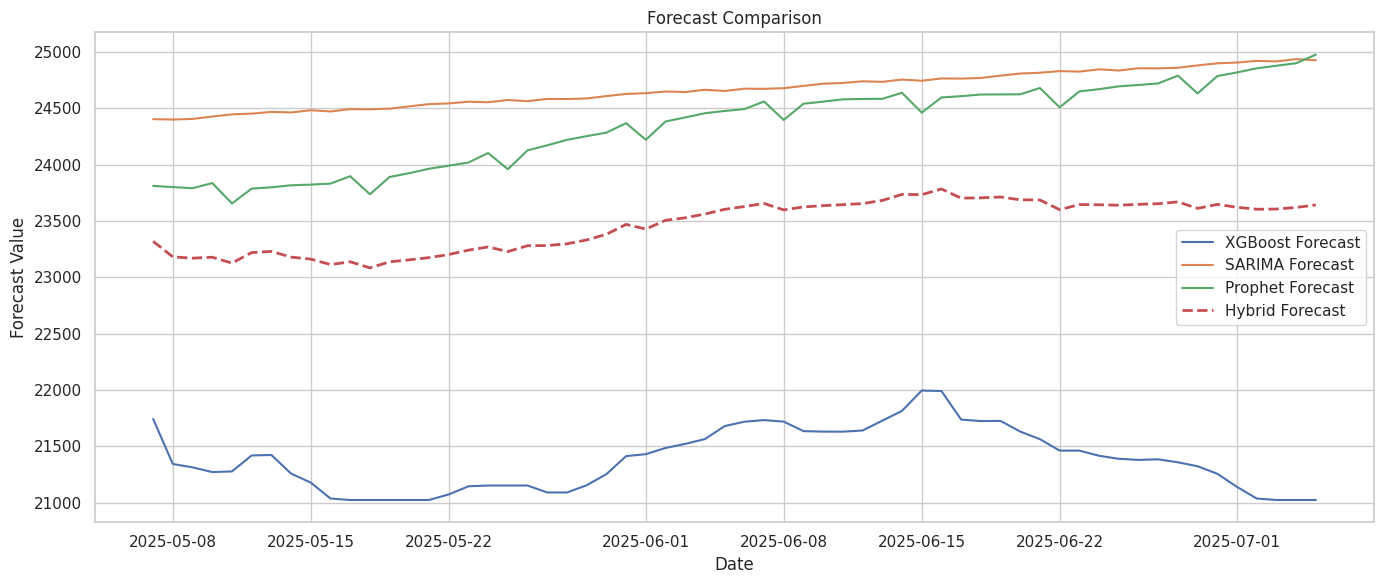

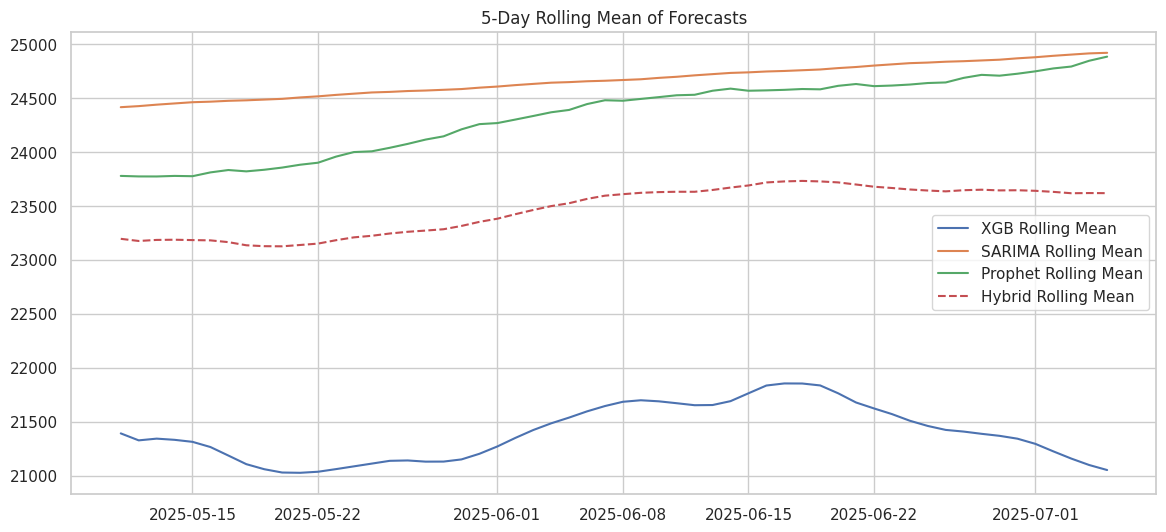

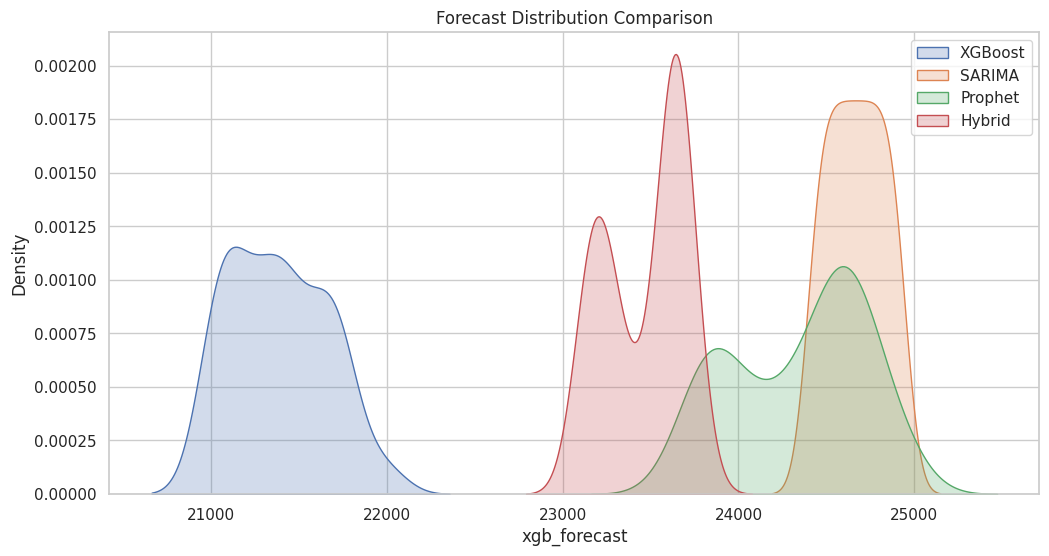


📋 Forecast Summary Statistics:
                          mean         std           min           max
xgb_forecast      21385.174933  272.820972  21025.154000  21996.030000
sarima_forecast   24669.194037  158.937575  24400.710932  24936.720954
prophet_forecast  24342.968883  372.993946  23655.744077  24976.880757
hybrid_forecast   23465.779296  220.809036  23084.795086  23784.548554

📉 Forecast Errors (vs Hybrid as baseline):
xgb_forecast -> RMSE: 2091.24, MAE: 2080.60
sarima_forecast -> RMSE: 1208.61, MAE: 1203.41
prophet_forecast -> RMSE: 896.41, MAE: 877.19


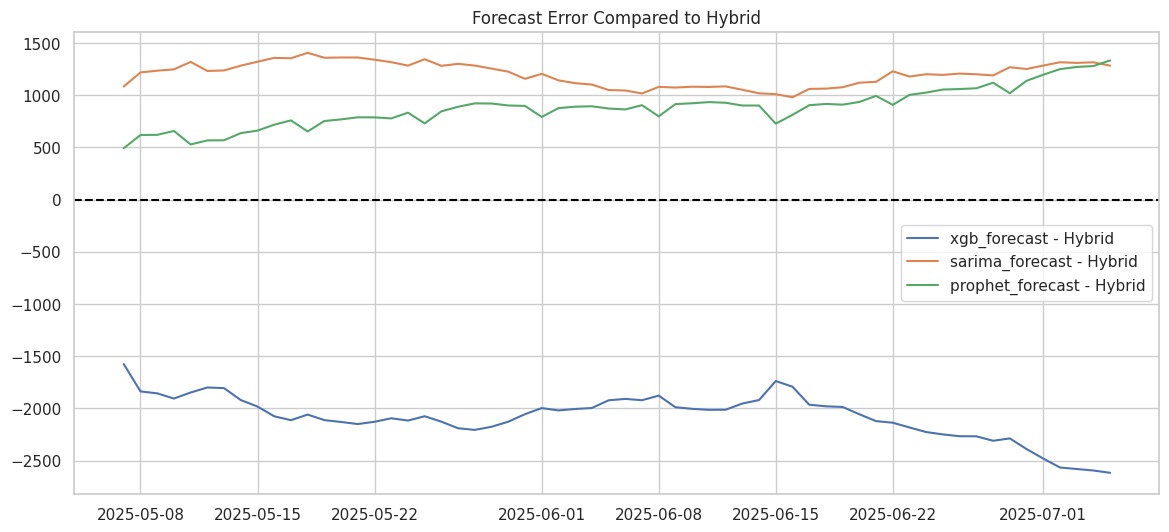

In [ ]:
# results = pd.read_csv()
# results

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Load the data (update path as needed)
results = pd.read_csv("/content/drive/MyDrive/hybrid_60_day_forecast.csv", parse_dates=['date'])

# Set date as index for easier time series plotting
results.set_index('date', inplace=True)

# -------------------------------
# 📊 1. Line Plot of Forecasts
# -------------------------------
plt.figure(figsize=(14, 6))
plt.plot(results.index, results['xgb_forecast'], label='XGBoost Forecast')
plt.plot(results.index, results['sarima_forecast'], label='SARIMA Forecast')
plt.plot(results.index, results['prophet_forecast'], label='Prophet Forecast')
plt.plot(results.index, results['hybrid_forecast'], label='Hybrid Forecast', linestyle='--', linewidth=2)
plt.title("Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Forecast Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------------
# 📈 2. Rolling Mean (Trend Analysis)
# -----------------------------------
rolling = results.rolling(window=5).mean()

plt.figure(figsize=(14, 6))
plt.plot(rolling['xgb_forecast'], label='XGB Rolling Mean')
plt.plot(rolling['sarima_forecast'], label='SARIMA Rolling Mean')
plt.plot(rolling['prophet_forecast'], label='Prophet Rolling Mean')
plt.plot(rolling['hybrid_forecast'], label='Hybrid Rolling Mean', linestyle='--')
plt.title("5-Day Rolling Mean of Forecasts")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# 📉 3. Forecast Distribution
# -------------------------
plt.figure(figsize=(12, 6))
sns.kdeplot(results['xgb_forecast'], label='XGBoost', fill=True)
sns.kdeplot(results['sarima_forecast'], label='SARIMA', fill=True)
sns.kdeplot(results['prophet_forecast'], label='Prophet', fill=True)
sns.kdeplot(results['hybrid_forecast'], label='Hybrid', fill=True)
plt.title("Forecast Distribution Comparison")
plt.legend()
plt.show()

# -------------------------
# 📋 4. Basic Statistics Table
# -------------------------
stats = results.describe().T[['mean', 'std', 'min', 'max']]
print("\n📋 Forecast Summary Statistics:")
print(stats)

# ------------------------------------------------
# ✅ 5. Error Metrics (Assume hybrid is true value)
# ------------------------------------------------
print("\n📉 Forecast Errors (vs Hybrid as baseline):")
for model in ['xgb_forecast', 'sarima_forecast', 'prophet_forecast']:
    rmse = np.sqrt(mean_squared_error(results['hybrid_forecast'], results[model]))
    mae = mean_absolute_error(results['hybrid_forecast'], results[model])
    print(f"{model} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}")

# -----------------------------
# 🔁 6. Forecast Differences Plot
# -----------------------------
results_diff = results[['xgb_forecast', 'sarima_forecast', 'prophet_forecast']].subtract(results['hybrid_forecast'], axis=0)

plt.figure(figsize=(14, 6))
for col in results_diff.columns:
    plt.plot(results_diff.index, results_diff[col], label=f'{col} - Hybrid')
plt.axhline(0, color='black', linestyle='--')
plt.title("Forecast Error Compared to Hybrid")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import glob
glob.glob('hy*.csv')

[]

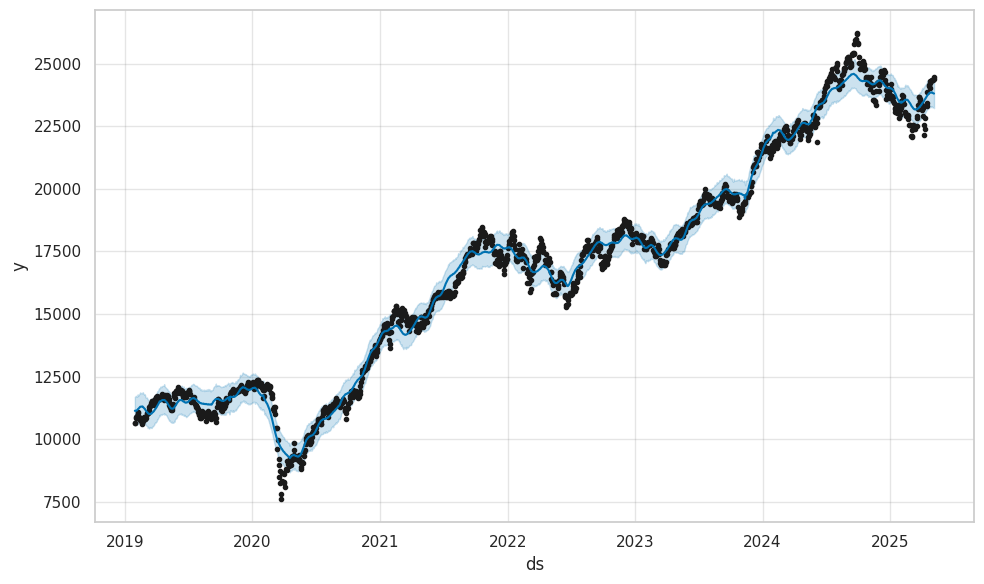

In [ ]:
prophet.plot(prophet_forecast_df)
plt.show()

In [ ]:
results = pd.read_csv('/content/drive/MyDrive/hybrid_60_day_forecast.csv')
results

,date,xgb_forecast,sarima_forecast,prophet_forecast,hybrid_forecast
0,2025-05-07,21743.928,24404.047689,23811.993845,23319.989756
1,2025-05-08,21344.260,24400.710932,23801.299046,23182.089915
2,2025-05-09,21314.547,24406.443526,23791.409267,23170.799889
3,2025-05-10,21272.816,24427.149197,23836.982084,23178.982562
4,2025-05-11,21278.684,24446.694514,23655.744077,23127.040728
5,2025-05-12,21420.207,24453.183914,23787.771708,23220.387551
6,2025-05-13,21424.418,24468.332282,23799.370155,23230.706802
7,2025-05-14,21259.398,24463.535697,23817.261363,23180.065166
8,2025-05-15,21179.380,24483.611603,23823.461619,23162.151360
9,2025-05-16,21037.932,24472.358267,23832.217979,23114.169296


<Axes: >

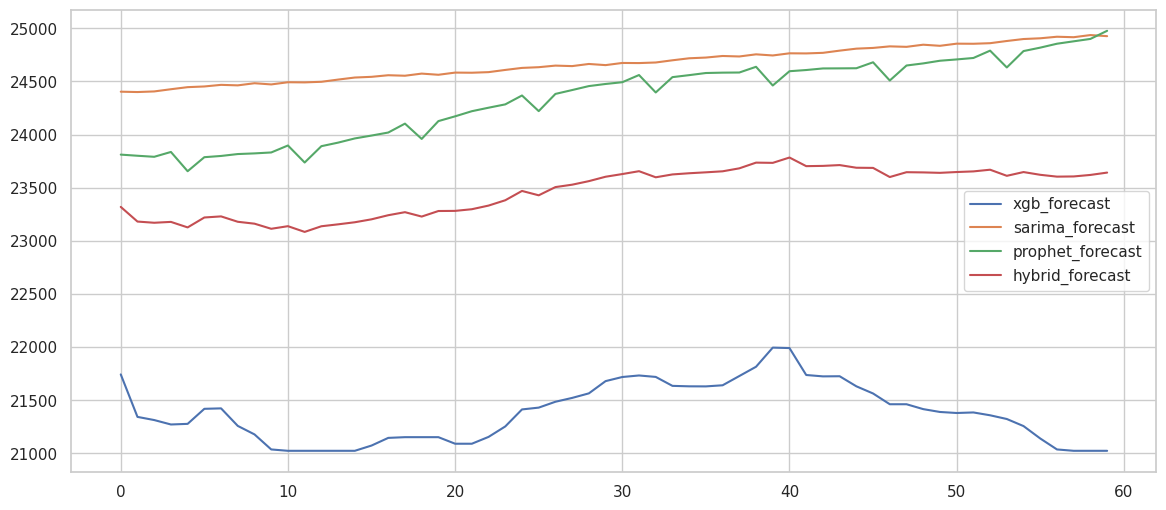

In [ ]:
results.plot()

<Axes: xlabel='date'>

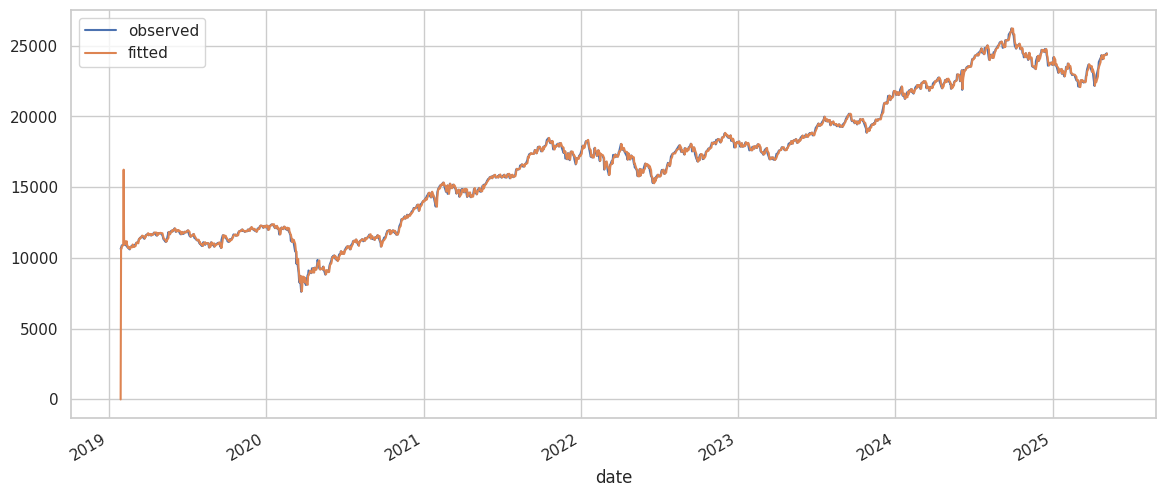

In [ ]:
sarima_df = pd.DataFrame()
sarima_df['observed'] = df['price']
sarima_df.index = df['date']
sarima_df['fitted'] =sarima_fitted.values
sarima_df.plot()

<Axes: >

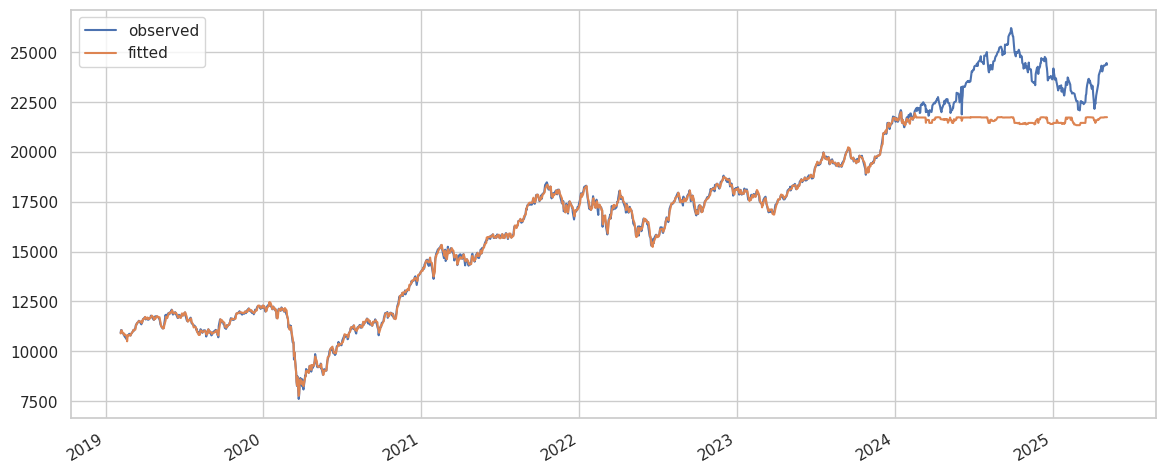

In [ ]:
xgb_df = pd.DataFrame()
xgb_df['observed'] = df['price'].iloc[5:].values
xgb_df.index = df['date'].iloc[5:].values
xgb_df['fitted'] =xgb_fitted
xgb_df.plot()

<Axes: xlabel='date'>

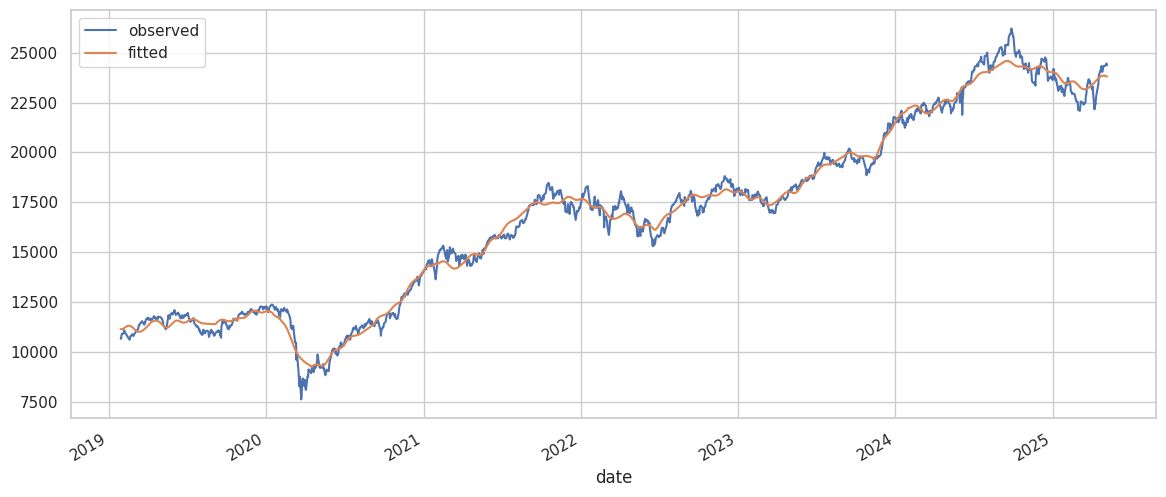

In [ ]:
prophet_df = pd.DataFrame()
prophet_df['observed'] = df['price']
prophet_df.index = df['date']
prophet_df['fitted'] =prophet_fitted
prophet_df.plot()

In [ ]:
results[['date','xgb_forecast']]

,date,xgb_forecast
0,2025-05-07,21743.928
1,2025-05-08,21344.260
2,2025-05-09,21314.547
3,2025-05-10,21272.816
4,2025-05-11,21278.684
5,2025-05-12,21420.207
6,2025-05-13,21424.418
7,2025-05-14,21259.398
8,2025-05-15,21179.380
9,2025-05-16,21037.932


In [ ]:
results[['date','prophet_forecast']]

,date,prophet_forecast
0,2025-05-07,23811.993845
1,2025-05-08,23801.299046
2,2025-05-09,23791.409267
3,2025-05-10,23836.982084
4,2025-05-11,23655.744077
5,2025-05-12,23787.771708
6,2025-05-13,23799.370155
7,2025-05-14,23817.261363
8,2025-05-15,23823.461619
9,2025-05-16,23832.217979


In [ ]:
results[['date','sarima_forecast']]

,date,sarima_forecast
0,2025-05-07,24404.047689
1,2025-05-08,24400.710932
2,2025-05-09,24406.443526
3,2025-05-10,24427.149197
4,2025-05-11,24446.694514
5,2025-05-12,24453.183914
6,2025-05-13,24468.332282
7,2025-05-14,24463.535697
8,2025-05-15,24483.611603
9,2025-05-16,24472.358267


In [ ]:
pwd


'/content'